In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    ID_COL,
    TARGET_COL,
    RANDOM_STATE,
    PROCESSED_DATA_DIR,
    SUBMISSION_DIR,
    REPORT_DIR,
    FIG_DIR,
)
from src.data_loader import load_application_data
from src.preprocessing import prepare_main_table_with_bureau
from src.train import train_catboost_cv
from src.features_bureau import build_bureau_features

In [2]:
train, test, sample_sub, data_dir = load_application_data()

bureau_path = PROCESSED_DATA_DIR / "bureau_features.parquet"

if bureau_path.exists():
    bureau_features = pd.read_parquet(bureau_path)
else:
    bureau_features = build_bureau_features(save=True)

print("DATA_DIR:", data_dir)
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Bureau features shape:", bureau_features.shape)

display(bureau_features.head())

DATA_DIR: C:\Coding\Home-Credit-Default-Risk\data\raw
Train shape: (307511, 122)
Test shape : (48744, 121)
Bureau features shape: (356255, 37)


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM,BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM,BUREAU_HAS_DEBT_SUM,BUREAU_HAS_OVERDUE_SUM,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DEBT_CREDIT_RATIO_MEAN,BUREAU_OVERDUE_DEBT_RATIO_MEAN,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_STATUS_0_MEAN_MEAN,BUREAU_BB_STATUS_1_MEAN_MEAN,BUREAU_BB_STATUS_2_MEAN_MEAN,BUREAU_BB_STATUS_3_MEAN_MEAN,BUREAU_BB_STATUS_4_MEAN_MEAN,BUREAU_BB_STATUS_5_MEAN_MEAN,BUREAU_BB_STATUS_C_MEAN_MEAN,BUREAU_BB_STATUS_X_MEAN_MEAN,BUREAU_BB_STATUS_0_SUM_SUM,BUREAU_BB_STATUS_1_SUM_SUM,BUREAU_BB_STATUS_2_SUM_SUM,BUREAU_BB_STATUS_3_SUM_SUM,BUREAU_BB_STATUS_4_SUM_SUM,BUREAU_BB_STATUS_5_SUM_SUM,BUREAU_BB_STATUS_C_SUM_SUM,BUREAU_BB_STATUS_X_SUM_SUM,BUREAU_ACTIVE_RATIO,BUREAU_CLOSED_RATIO,BUREAU_OVERDUE_RATIO
0,100002,8.000000,2.000000,6.000000,1.000000,0.000000,-874.000000,-103.000000,-499.875000,"108,131.945625","865,055.565000","49,156.200000","245,781.000000",0.000000,0.136545,0.000000,13.750000,22.000000,0.406960,0.255682,0.000000,0.000000,0.000000,0.000000,0.175426,0.161932,45.000000,27.000000,0.000000,0.000000,0.000000,0.000000,23.000000,15.000000,0.250000,0.750000,0.000000
1,100003,4.000000,1.000000,3.000000,0.000000,0.000000,"-1,400.750000",-606.000000,-816.000000,"254,350.125000","1,017,400.500000",0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.750000,0.000000
2,100004,2.000000,0.000000,2.000000,0.000000,0.000000,-867.000000,-408.000000,-532.000000,"94,518.900000","189,037.800000",0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,1.000000,0.000000,1.000000,0.000000,0.000000,"-1,149.000000","-1,149.000000",-783.000000,"146,250.000000","146,250.000000",0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [3]:
print("Rows in bureau_features:", len(bureau_features))
print("Unique SK_ID_CURR:", bureau_features[ID_COL].nunique())
print("Is unique key:", bureau_features[ID_COL].is_unique)

bureau_cols = [c for c in bureau_features.columns if c != ID_COL]
print("Number of bureau-derived columns:", len(bureau_cols))

display(
    bureau_features[bureau_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

Rows in bureau_features: 356255
Unique SK_ID_CURR: 356255
Is unique key: True
Number of bureau-derived columns: 36


BUREAU_BB_STATUS_1_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_X_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_5_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_4_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_3_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_2_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_0_MEAN_MEAN      0.622344
BUREAU_BB_MONTHS_COUNT_MAX        0.622344
BUREAU_BB_MONTHS_COUNT_MEAN       0.622344
BUREAU_BB_STATUS_C_MEAN_MEAN      0.622344
BUREAU_OVERDUE_DEBT_RATIO_MEAN    0.391489
BUREAU_DEBT_CREDIT_RATIO_MEAN     0.169210
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN   0.165095
BUREAU_AMT_CREDIT_SUM_MEAN        0.141601
BUREAU_BB_STATUS_2_SUM_SUM        0.141595
BUREAU_BB_STATUS_3_SUM_SUM        0.141595
BUREAU_BB_STATUS_4_SUM_SUM        0.141595
BUREAU_BB_STATUS_5_SUM_SUM        0.141595
BUREAU_BB_STATUS_0_SUM_SUM        0.141595
BUREAU_BB_STATUS_C_SUM_SUM        0.141595
dtype: float64

In [4]:
X, y, X_test, test_ids, categorical_cols, numeric_cols = prepare_main_table_with_bureau(
    train=train,
    test=test,
    bureau_features=bureau_features,
)

print("Merged train features:", X.shape)
print("Merged test features :", X_test.shape)
print("Categorical columns  :", len(categorical_cols))
print("Numeric columns      :", len(numeric_cols))

bureau_feature_names = [c for c in X.columns if c.startswith("BUREAU_")]
print("Merged bureau feature count:", len(bureau_feature_names))

display(pd.Series(bureau_feature_names[:30], name="bureau_features_preview"))

Merged train features: (307511, 157)
Merged test features : (48744, 157)
Categorical columns  : 16
Numeric columns      : 141
Merged bureau feature count: 36


0              BUREAU_SK_ID_BUREAU_COUNT
1     BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM
2     BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM
3                    BUREAU_HAS_DEBT_SUM
4                 BUREAU_HAS_OVERDUE_SUM
5                BUREAU_DAYS_CREDIT_MEAN
6                 BUREAU_DAYS_CREDIT_MAX
7         BUREAU_DAYS_CREDIT_UPDATE_MEAN
8             BUREAU_AMT_CREDIT_SUM_MEAN
9              BUREAU_AMT_CREDIT_SUM_SUM
10       BUREAU_AMT_CREDIT_SUM_DEBT_MEAN
11        BUREAU_AMT_CREDIT_SUM_DEBT_SUM
12     BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX
13         BUREAU_DEBT_CREDIT_RATIO_MEAN
14        BUREAU_OVERDUE_DEBT_RATIO_MEAN
15           BUREAU_BB_MONTHS_COUNT_MEAN
16            BUREAU_BB_MONTHS_COUNT_MAX
17          BUREAU_BB_STATUS_0_MEAN_MEAN
18          BUREAU_BB_STATUS_1_MEAN_MEAN
19          BUREAU_BB_STATUS_2_MEAN_MEAN
20          BUREAU_BB_STATUS_3_MEAN_MEAN
21          BUREAU_BB_STATUS_4_MEAN_MEAN
22          BUREAU_BB_STATUS_5_MEAN_MEAN
23          BUREAU_BB_STATUS_C_MEAN_MEAN
24          BURE

In [5]:
results = train_catboost_cv(
    X=X,
    y=y,
    X_test=X_test,
    categorical_cols=categorical_cols,
    random_state=RANDOM_STATE,
)

baseline_mean_auc = 0.759922
baseline_oof_auc = 0.759895

print("Fold AUC scores:", [round(score, 6) for score in results["fold_scores"]])
print("Mean fold AUC :", round(np.mean(results["fold_scores"]), 6))
print("OOF AUC       :", round(results["overall_auc"], 6))
print("Lift vs baseline OOF:", round(results["overall_auc"] - baseline_oof_auc, 6))

Fold 1 AUC: 0.760744
Fold 2 AUC: 0.770255
Fold 3 AUC: 0.764195
Fold 4 AUC: 0.770144
Fold 5 AUC: 0.761541
Fold AUC scores: [0.760744, 0.770255, 0.764195, 0.770144, 0.761541]
Mean fold AUC : 0.765376
OOF AUC       : 0.765354
Lift vs baseline OOF: 0.005459


In [6]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: results["test_preds"],
})

submission_path = SUBMISSION_DIR / "model_v2_bureau.csv"
submission.to_csv(submission_path, index=False)

comparison_df = pd.DataFrame({
    "model": ["baseline_main_table", "main_table_plus_bureau"],
    "mean_fold_auc": [baseline_mean_auc, np.mean(results["fold_scores"])],
    "oof_auc": [baseline_oof_auc, results["overall_auc"]],
})

comparison_df["oof_lift_vs_baseline"] = comparison_df["oof_auc"] - baseline_oof_auc

print("Submission saved to:", submission_path)
display(submission.head())
display(comparison_df)

Submission saved to: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v2_bureau.csv


,SK_ID_CURR,TARGET
0,100001,0.292829
1,100005,0.678310
2,100013,0.174254
3,100028,0.257261
4,100038,0.661344


,model,mean_fold_auc,oof_auc,oof_lift_vs_baseline
0,baseline_main_table,0.759922,0.759895,0.000000
1,main_table_plus_bureau,0.765376,0.765354,0.005459


,feature,importance,source
75,EXT_SOURCE_3,13.988113,main_table
74,EXT_SOURCE_2,10.833175,main_table
73,EXT_SOURCE_1,6.364396,main_table
1,AMT_CREDIT,4.610291,main_table
58,DAYS_BIRTH,4.190686,main_table
2,AMT_GOODS_PRICE,3.979123,main_table
0,AMT_ANNUITY,3.630004,main_table
46,BUREAU_DEBT_CREDIT_RATIO_MEAN,3.281401,bureau
59,DAYS_EMPLOYED,3.180165,main_table
125,NAME_EDUCATION_TYPE,1.963163,main_table


Top bureau features:


,feature,importance,source
46,BUREAU_DEBT_CREDIT_RATIO_MEAN,3.281401,bureau
19,BUREAU_AMT_CREDIT_SUM_MEAN,1.653535,bureau
43,BUREAU_DAYS_CREDIT_MAX,1.544793,bureau
21,BUREAU_AMT_CREDIT_SUM_SUM,1.180547,bureau
18,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,1.010969,bureau
41,BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM,0.914302,bureau
17,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,0.876273,bureau
44,BUREAU_DAYS_CREDIT_MEAN,0.628434,bureau
24,BUREAU_BB_STATUS_0_MEAN_MEAN,0.589155,bureau
45,BUREAU_DAYS_CREDIT_UPDATE_MEAN,0.555244,bureau


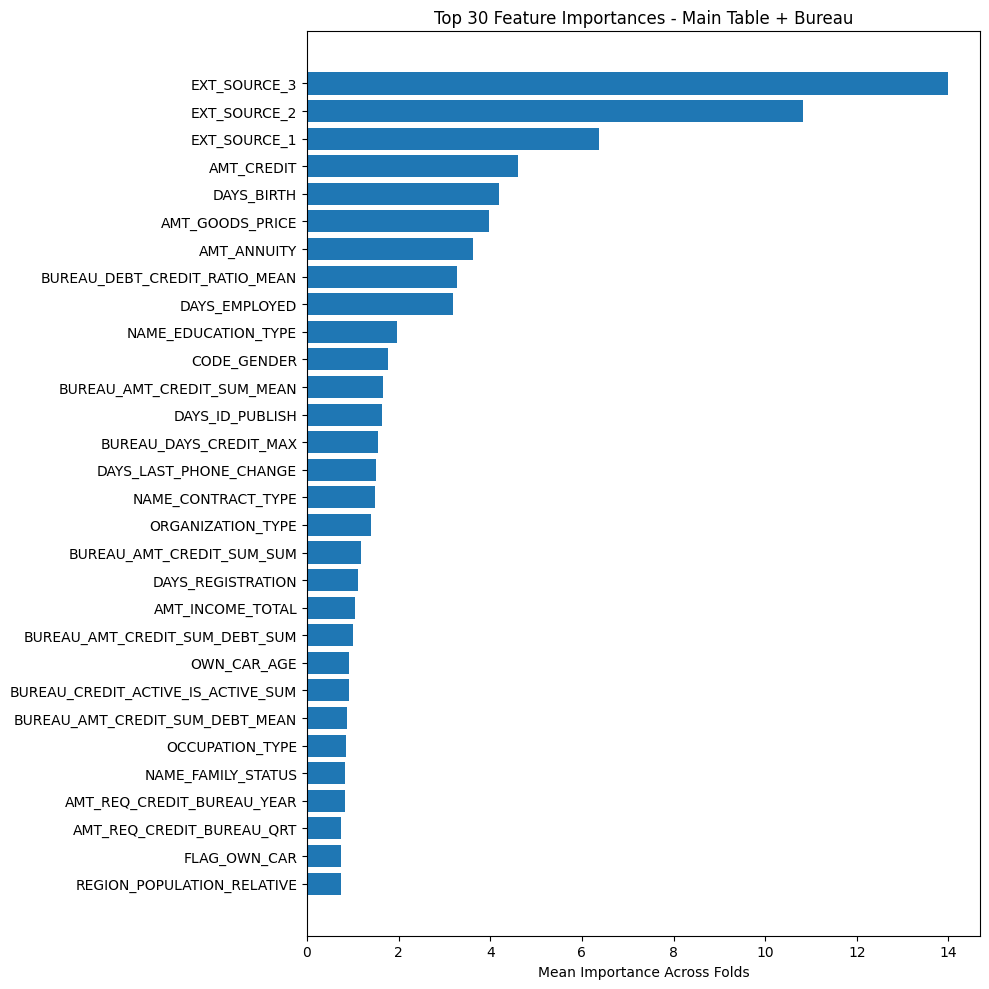

Figure saved to: C:\Coding\Home-Credit-Default-Risk\outputs\figures\model_v2_bureau_feature_importance.png


In [7]:
feature_importance = results["feature_importance"].copy()
feature_importance["source"] = np.where(
    feature_importance["feature"].str.startswith("BUREAU_"),
    "bureau",
    "main_table",
)

display(feature_importance.head(30))

top_bureau_features = feature_importance[
    feature_importance["feature"].str.startswith("BUREAU_")
].head(15)

print("Top bureau features:")
display(top_bureau_features)

plot_df = feature_importance.head(30).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 30 Feature Importances - Main Table + Bureau")
plt.xlabel("Mean Importance Across Folds")
plt.tight_layout()

fig_path = FIG_DIR / "model_v2_bureau_feature_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", fig_path)

In [8]:
report_lines = [
    "# Model V2 Results - Main Table + Bureau",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Bureau feature table shape: {bureau_features.shape}",
    f"- Final merged train feature matrix: {X.shape}",
    f"- Final merged test feature matrix: {X_test.shape}",
    f"- Number of categorical columns: {len(categorical_cols)}",
    f"- Number of numeric columns: {len(numeric_cols)}",
    f"- Number of bureau-derived columns used in model: {len(bureau_feature_names)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {results['n_splits']}",
    f"- Fold AUC scores: {[round(score, 6) for score in results['fold_scores']]}",
    f"- Mean fold AUC: {np.mean(results['fold_scores']):.6f}",
    f"- OOF AUC: {results['overall_auc']:.6f}",
    "",
    "## Baseline Comparison",
    f"- Baseline mean fold AUC: {baseline_mean_auc:.6f}",
    f"- Baseline OOF AUC: {baseline_oof_auc:.6f}",
    f"- OOF lift vs baseline: {results['overall_auc'] - baseline_oof_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- Feature importance figure: {fig_path}",
    "",
    "## Notes",
    "- This model adds bureau and bureau_balance aggregated features on top of the main application table.",
    "- Compare whether external credit history improves discrimination over the baseline-only model.",
]

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "model_v2_with_bureau.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Report saved to:", report_path)

Report saved to: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v2_with_bureau.md
